# Day 3-3: 하이퍼파라미터 튜닝 with Optuna & MLflow

**강의 시간**: 2시간  
**학습 목표**:
- Custom Hybrid 모델 개선 (94% → 98%+)
- Manual Grid Search 수행
- Optuna 자동 하이퍼파라미터 탐색
- MLflow 실험 추적 및 비교
- 체계적인 튜닝 방법론 학습
- 실패한 모델을 성공시키는 경험

**사전 요구사항**: Day 3-2 완료  
**목표 성능**: Custom Hybrid 94.07% → 98.5%+

## 🎯 0. 왜 하이퍼파라미터 튜닝인가?

### 0.1 Day 3-2의 교훈

**실험 결과:**
```
ResNet_style   : 99.12% ✅ 최고!
Simple_CNN     : 99.07%
VGG_style      : 98.67%
LeNet5         : 98.50%
SE_CNN         : 96.45%
Custom_Hybrid  : 94.07% ❌ 최악!
```

**문제:**
- Custom Hybrid가 가장 복잡한데 성능이 최악
- 하이퍼파라미터 미최적화
- Learning Rate 불일치
- Gamma 초기화 문제 (0 시작)
- Epoch 부족

**우리의 목표:**
```
Custom Hybrid: 94.07% → 98.5%+
실패한 모델을 성공시키는 과정!
```

## 🔧 1. 환경 설정

In [ ]:
# 라이브러리 설치
%pip install -q 'mlflow>=2,<3' dagshub tensorflow scikit-learn optuna

print("✅ 라이브러리 설치 완료!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 114.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.4/263.4 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.4/808.4 kB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install optuna-integration[mlflow]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 4.5 MB/s eta 0:00:00


In [ ]:
# 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Dense, Dropout,
    BatchNormalization, Activation, GlobalAveragePooling2D,
    Reshape, Multiply, Layer
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# MLflow & Optuna
import mlflow
import dagshub
import optuna
from optuna.integration.mlflow import MLflowCallback

# 재현성
np.random.seed(42)
tf.random.set_seed(42)

print(f"✅ TensorFlow {tf.__version__}")
print(f"✅ Optuna {optuna.__version__}")
print(f"✅ GPU: {tf.test.is_gpu_available()}")

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


✅ TensorFlow 2.19.0
✅ Optuna 4.7.0
✅ GPU: True


In [ ]:
# 시각화 설정
sns.set_style('whitegrid')

# 1) 폰트 파일 직접 다운로드 (런타임 재시작 불필요)
!wget -q -O NanumGothic.ttf -L "https://fonts.gstatic.com/ea/nanumgothic/v5/NanumGothic-Regular.ttf"

import matplotlib.font_manager as fm

# 폰트 파일 경로
font_path = "NanumGothic.ttf"

# 폰트 매니저에 폰트 추가
fm.fontManager.addfont(font_path)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# 폰트 속성 설정
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
# Dagshub & MLflow
# 🔥 본인의 정보로 수정!
repo_owner = 'dev.codecompose'  # 본인의 Dagshub username
repo_name = 'deeplearning-bootcamp'  # 생성한 repository 이름 (예: deeplearning-bootcamp)

dagshub.init(repo_owner=repo_owner, repo_name=repo_name, mlflow=True)
mlflow.set_experiment('day3-mnist-digit-recognizer')
exp_id = mlflow.get_experiment_by_name('day3-mnist-digit-recognizer').experiment_id

print("✅ MLflow 설정 완료!")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=301de742-092b-4597-bfd1-230e96910900&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=e18dbfc8abc81f1139584fe1bc049d9f8101c47f6b7a55b35a4c28aebcbd4196




Output()

Accessing as dev.codecompose

Initialized MLflow to track repo "dev.codecompose/deeplearning-bootcamp"

Repository dev.codecompose/deeplearning-bootcamp initialized!

✅ MLflow 설정 완료!


## 📂 2. 데이터 로드

#### Google Drive 연동

실험 결과와 데이터를 저장하기 위해 Google Drive를 연결합니다.

🔐 **실행하면 인증 링크가 나타납니다. 클릭해서 권한을 승인하세요.**

In [ ]:
# from google.colab import drive

# # Google Drive 마운트
# drive.mount('/content/drive')

# print("\n✅ Google Drive 연결 완료!")
# print("📁 Drive 경로: /content/drive/MyDrive")

Mounted at /content/drive

✅ Google Drive 연결 완료!
📁 Drive 경로: /content/drive/MyDrive


In [ ]:
# import os

# # 폴더 구조 생성
# # base_path = '/content/drive/MyDrive/deeplearning-bootcamp'
# base_path = '/content/drive/MyDrive/lectures/dl_bootcamp'
# day3_path = os.path.join(base_path, 'day3_mnist_digit_recognizer')
# data_path = os.path.join(day3_path, 'data/digit-recognizer')

# os.makedirs(data_path, exist_ok=True)

# print("✅ 폴더 생성 완료!")
# print(f"📁 Base: {base_path}")
# print(f"📁 Day 3: {day3_path}")
# print(f"📁 Data: {data_path}")

✅ 폴더 생성 완료!
📁 Base: /content/drive/MyDrive/lectures/dl_bootcamp
📁 Day 3: /content/drive/MyDrive/lectures/dl_bootcamp/day3_mnist_digit_recognizer
📁 Data: /content/drive/MyDrive/lectures/dl_bootcamp/day3_mnist_digit_recognizer/data/digit-recognizer


#### 직접 업로드

In [ ]:
import os
import zipfile
from google.colab import files

# 1. 경로 설정: /content/data/digit-recognizer 폴더 생성
# 다른 데이터와 섞이지 않게 전용 하위 폴더를 지정합니다.
base_data_path = '/content/data'
target_path = os.path.join(base_data_path, 'digit-recognizer')

os.makedirs(target_path, exist_ok=True)

# 2. 파일 업로드
print("📤 'digit-recognizer.zip' 파일을 선택해주세요...")
uploaded = files.upload()

# 3. 압축 해제 로직
zip_file_name = 'digit-recognizer.zip'

if zip_file_name in uploaded:
    print(f"\n📦 {zip_file_name}을(를) {target_path}에 압축 해제 중...")
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        # target_path(/content/data/digit-recognizer)에 압축 해제
        zip_ref.extractall(target_path)
    print(f"✅ 압축 해제 완료: {target_path}")

    # 세션 용량 확보를 위해 업로드된 zip 파일 삭제 (선택 사항)
    os.remove(zip_file_name)
else:
    print(f"\n⚠️ {zip_file_name} 파일이 업로드되지 않았습니다.")

# 4. 결과 확인
print(f"\n📂 {target_path} 내부 파일 목록:")
print(os.listdir(target_path))

📤 'digit-recognizer.zip' 파일을 선택해주세요...


Saving digit-recognizer.zip to digit-recognizer.zip

📦 digit-recognizer.zip을(를) /content/data/digit-recognizer에 압축 해제 중...
✅ 압축 해제 완료: /content/data/digit-recognizer

📂 /content/data/digit-recognizer 내부 파일 목록:
['sample_submission.csv', 'test.csv', 'train.csv']


In [ ]:
data_path = target_path

#### 데이터 로드

In [ ]:
# 데이터 로드
# Kaggle에서 직접 다운로드하여 Google Drive에 업로드한 파일을 로드합니다.
train_df = pd.read_csv(os.path.join(data_path, 'train.csv'))
test_df = pd.read_csv(os.path.join(data_path, 'test.csv'))

print(f"✅ Train shape: {train_df.shape}")
print(f"✅ Test shape : {test_df.shape}")
print()
print("Train 첫 5행:")
train_df.head()

✅ Train shape: (42000, 785)
✅ Test shape : (28000, 784)

Train 첫 5행:


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Day 3-1, 3-2와 동일
y_train = train_df['label'].values
X_train = train_df.drop('label', axis=1).values
X_test = test_df.values

# 전처리
X_train = X_train / 255.0
X_test = X_test / 255.0
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Split
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)

print(f"✅ Train: {X_train_sub.shape}")
print(f"✅ Val  : {X_val.shape}")

✅ Train: (37800, 28, 28, 1)
✅ Val  : (4200, 28, 28, 1)


## 🏗️ 3. Custom Hybrid 모델 (개선 버전)

In [ ]:
class SelfAttention(Layer):
    """Self-Attention Layer with configurable gamma initialization"""
    def __init__(self, channels, gamma_init=0.5, **kwargs):
        super(SelfAttention, self).__init__(**kwargs)
        self.channels = channels
        self.gamma_init = gamma_init

    def build(self, input_shape):
        self.query = Conv2D(self.channels // 8, (1, 1))
        self.key = Conv2D(self.channels // 8, (1, 1))
        self.value = Conv2D(self.channels, (1, 1))

        # Gamma 초기화를 설정 가능하게
        self.gamma = self.add_weight(
            name='gamma',
            shape=(1,),
            initializer=tf.keras.initializers.Constant(self.gamma_init),
            trainable=True
        )

        super(SelfAttention, self).build(input_shape)

    def call(self, x):
        batch, height, width, channels = x.shape

        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        q = tf.reshape(q, [-1, height * width, self.channels // 8])
        k = tf.reshape(k, [-1, height * width, self.channels // 8])
        v = tf.reshape(v, [-1, height * width, self.channels])

        attention = tf.matmul(q, k, transpose_b=True)
        attention = tf.nn.softmax(attention, axis=-1)

        out = tf.matmul(attention, v)
        out = tf.reshape(out, [-1, height, width, self.channels])

        out = self.gamma * out + x

        return out

def build_custom_hybrid(dropout=0.5, gamma_init=0.5, conv_filters=[32, 64, 128]):
    """Custom Hybrid with configurable hyperparameters"""
    inputs = Input(shape=(28, 28, 1))

    # Conv Feature Extraction
    x = Conv2D(conv_filters[0], (3, 3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(conv_filters[1], (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)

    # Self-Attention
    x = SelfAttention(conv_filters[1], gamma_init=gamma_init)(x)

    # Conv Refinement
    x = Conv2D(conv_filters[2], (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)

    # Classifier
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(dropout)(x)
    outputs = Dense(10, activation='softmax')(x)

    model = Model(inputs, outputs, name='Custom_Hybrid_Tuned')
    return model

print("✅ Custom Hybrid 모델 정의 완료!")

✅ Custom Hybrid 모델 정의 완료!


## 🔍 4. Manual Grid Search

### 4.1 Learning Rate 탐색

**가설**: Custom Hybrid에 lr=0.001은 너무 클 수 있다

In [ ]:
# Learning Rate 후보
lr_candidates = [0.0001, 0.0005, 0.001, 0.002]

lr_results = []

for lr in lr_candidates:
    print(f"\n{'='*60}")
    print(f"Testing lr={lr}")
    print('='*60)

    try:
        mlflow.end_run()
    except:
        pass

    with mlflow.start_run(run_name=f'Manual_LR_{lr}'):
        # 모델 생성
        model = build_custom_hybrid(dropout=0.5, gamma_init=0.5)
        model.compile(
            optimizer=Adam(learning_rate=lr),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        # 파라미터 로깅
        mlflow.log_params({
            'model': 'Custom_Hybrid',
            'tuning': 'manual_lr',
            'lr': lr,
            'dropout': 0.5,
            'gamma_init': 0.5,
            'epochs': 10
        })

        # 학습
        history = model.fit(
            X_train_sub, y_train_sub,
            batch_size=128,
            epochs=10,
            validation_data=(X_val, y_val),
            verbose=0
        )

        # 최종 성능
        val_acc = max(history.history['val_accuracy'])
        mlflow.log_metric('final_val_accuracy', val_acc)

        lr_results.append({'lr': lr, 'val_acc': val_acc})
        print(f"Val Accuracy: {val_acc:.4f}")

# 결과 정리
lr_df = pd.DataFrame(lr_results)
print("\n" + "="*60)
print("Learning Rate Grid Search Results")
print("="*60)
print(lr_df.to_string(index=False))
print("="*60)

best_lr = lr_df.loc[lr_df['val_acc'].idxmax(), 'lr']
print(f"\n✅ Best Learning Rate: {best_lr}")


Testing lr=0.0001
Val Accuracy: 0.9490
🏃 View run Manual_LR_0.0001 at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/4/runs/770389fc20eb4323a63596684be80a86
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/4

Testing lr=0.0005
Val Accuracy: 0.9664
🏃 View run Manual_LR_0.0005 at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/4/runs/776423294469439c861454bc7d3f04b2
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/4

Testing lr=0.001
Val Accuracy: 0.9669
🏃 View run Manual_LR_0.001 at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/4/runs/dbe178b84d9b455e9ebc164dbf864f71
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/4

Testing lr=0.002
Val Accuracy: 0.9750
🏃 View run Manual_LR_0.002 at: https://dagshub.com/dev.codecompose/deeplearning-b

### 4.2 Gamma 초기화 탐색

**가설**: gamma=0 (기본값)은 Attention을 비활성화

In [ ]:
# Gamma 초기화 후보
gamma_candidates = [0.0, 0.3, 0.5, 0.7, 1.0]

gamma_results = []

for gamma_init in gamma_candidates:
    print(f"\n{'='*60}")
    print(f"Testing gamma_init={gamma_init}")
    print('='*60)

    try:
        mlflow.end_run()
    except:
        pass

    with mlflow.start_run(run_name=f'Manual_Gamma_{gamma_init}'):
        model = build_custom_hybrid(dropout=0.5, gamma_init=gamma_init)
        model.compile(
            optimizer=Adam(learning_rate=0.0005),  # Best LR 사용
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        mlflow.log_params({
            'model': 'Custom_Hybrid',
            'tuning': 'manual_gamma',
            'lr': 0.0005,
            'dropout': 0.5,
            'gamma_init': gamma_init,
            'epochs': 10
        })

        history = model.fit(
            X_train_sub, y_train_sub,
            batch_size=128,
            epochs=10,
            validation_data=(X_val, y_val),
            verbose=0
        )

        val_acc = max(history.history['val_accuracy'])
        mlflow.log_metric('final_val_accuracy', val_acc)

        gamma_results.append({'gamma_init': gamma_init, 'val_acc': val_acc})
        print(f"Val Accuracy: {val_acc:.4f}")

# 결과 정리
gamma_df = pd.DataFrame(gamma_results)
print("\n" + "="*60)
print("Gamma Initialization Grid Search Results")
print("="*60)
print(gamma_df.to_string(index=False))
print("="*60)

best_gamma = gamma_df.loc[gamma_df['val_acc'].idxmax(), 'gamma_init']
print(f"\n✅ Best Gamma Init: {best_gamma}")


Testing gamma_init=0.0
Val Accuracy: 0.9600
🏃 View run Manual_Gamma_0.0 at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/4/runs/6b78808875c04de0a9d5c12356fe0b85
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/4

Testing gamma_init=0.3
Val Accuracy: 0.9540
🏃 View run Manual_Gamma_0.3 at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/4/runs/272e4a2ae1494b2fb8f4b690c139b029
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/4

Testing gamma_init=0.5
Val Accuracy: 0.9688
🏃 View run Manual_Gamma_0.5 at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/4/runs/444438b4d47d4512bddc76b18822088d
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/4

Testing gamma_init=0.7
Val Accuracy: 0.9567
🏃 View run Manual_Gamma_0.7 at: https://dagshub.com/dev.co

## 🤖 5. Optuna 자동 하이퍼파라미터 탐색

### 5.1 Objective 함수 정의

Optuna가 최적화할 목표 함수 작성

In [ ]:
def objective(trial):
    """Optuna objective function (Clean Version)"""

    # 1. 하이퍼파라미터 샘플링
    lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)
    dropout = trial.suggest_uniform('dropout', 0.2, 0.6)
    gamma_init = trial.suggest_uniform('gamma_init', 0.3, 1.0)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    epochs = trial.suggest_int('epochs', 15, 25)

    filter_option = trial.suggest_categorical('filter_option', [0, 1, 2])
    filter_options = [[32, 64, 128], [64, 128, 256], [32, 64, 128, 256]]
    conv_filters = filter_options[filter_option]

    # [핵심 변경] mlflow.start_run 블록을 완전히 제거합니다.
    # MLflowCallback이 밖에서 이미 Run을 열어놓았기 때문입니다.

    # 2. 모델 생성
    model = build_custom_hybrid(
        dropout=dropout,
        gamma_init=gamma_init,
        conv_filters=conv_filters
    )

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # 3. 학습 (EarlyStopping만 유지)
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_sub, y_train_sub,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=0
    )

    # 4. 성능 계산
    val_acc = max(history.history['val_accuracy'])

    # [핵심 변경] mlflow.log_metric 등도 제거합니다.
    # 콜백이 리턴값을 받아서 자동으로 기록합니다.

    # 5. Pruning (조기 종료)
    if val_acc < 0.95:
        raise optuna.TrialPruned()

    return val_acc

### 5.2 Optuna Study 실행

In [ ]:
import mlflow
import optuna
from optuna_integration import MLflowCallback

# 1. 실험 설정 및 ID 미리 확보
EXPERIMENT_NAME = 'day3-mnist-digit-recognizer'
mlflow.set_experiment(EXPERIMENT_NAME)
exp_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

# 2. 깨끗하게 청소
mlflow.end_run()

# 3. Study 생성
study = optuna.create_study(
    direction='maximize',
    study_name='custom_hybrid_tuning', # 이 이름은 이제 실험 이름으로 안 쓰입니다.
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5)
)

# 4. 부모 Run 시작
with mlflow.start_run(run_name='Optuna_Hybrid_Tuning_Group') as parent_run:

    # 5. [중요] 콜백을 'start_run' 안에서 새로 정의합니다.
    # 이렇게 해야 부모 Run의 존재를 콜백이 정확히 인지합니다.
    mlflc = MLflowCallback(
        tracking_uri=mlflow.get_tracking_uri(),
        metric_name='val_accuracy',
        mlflow_kwargs={
            "nested": True,
            "experiment_id": exp_id # 이름 대신 ID를 박아 넣는 게 가장 확실합니다.
        }
    )

    print(f"🚀 '{EXPERIMENT_NAME}' 내 {parent_run.info.run_id} 아래로 튜닝 시작...")

    study.optimize(
        objective,
        n_trials=3, # 테스트 완료 후 30으로 증설 추천!
        callbacks=[mlflc],
        show_progress_bar=True
    )

[I 2026-02-19 10:23:51,914] A new study created in memory with name: custom_hybrid_tuning


🚀 'day3-mnist-digit-recognizer' 내 4565636dab4e446f9f14b40625481524 아래로 튜닝 시작...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-02-19 10:26:50,716] Trial 0 finished with value: 0.9845238327980042 and parameters: {'lr': 0.006350392621696704, 'dropout': 0.5265086246241333, 'gamma_init': 0.9685987655797144, 'batch_size': 128, 'epochs': 17, 'filter_option': 1}. Best is trial 0 with value: 0.9845238327980042.
🏃 View run 0 at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/4/runs/e367dd3e14634a498b54eda447eaf10f
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/4
[I 2026-02-19 10:28:16,522] Trial 1 finished with value: 0.9633333086967468 and parameters: {'lr': 0.0001966724475216735, 'dropout': 0.2728372843040751, 'gamma_init': 0.5317571437759754, 'batch_size': 128, 'epochs': 20, 'filter_option': 0}. Best is trial 0 with value: 0.9845238327980042.
🏃 View run 1 at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/4/runs/7652395bcf764a5d95007955b9cfe7a4
🧪 View experiment at: https://dagshub.com/dev.co

In [ ]:
print(f"   Best Trial: {study.best_trial.number}")
print(f"   Best Score: {study.best_value:.4f}")
print(f"\n   Best Params:")
for key, value in study.best_params.items():
    print(f"     {key}: {value}")

   Best Trial: 0
   Best Score: 0.9845

   Best Params:
     lr: 0.006350392621696704
     dropout: 0.5265086246241333
     gamma_init: 0.9685987655797144
     batch_size: 128
     epochs: 17
     filter_option: 1


## 📊 6. Optuna 결과 시각화

In [ ]:
# 1. Optimization History
fig1 = optuna.visualization.plot_optimization_history(study)
fig1.show()

# 2. Parallel Coordinate Plot
fig2 = optuna.visualization.plot_parallel_coordinate(
    study,
    params=['lr', 'dropout', 'gamma_init', 'batch_size', 'epochs']
)
fig2.show()

# 3. Parameter Importances
fig3 = optuna.visualization.plot_param_importances(study)
fig3.show()

# 4. Slice Plot
fig4 = optuna.visualization.plot_slice(study)
fig4.show()

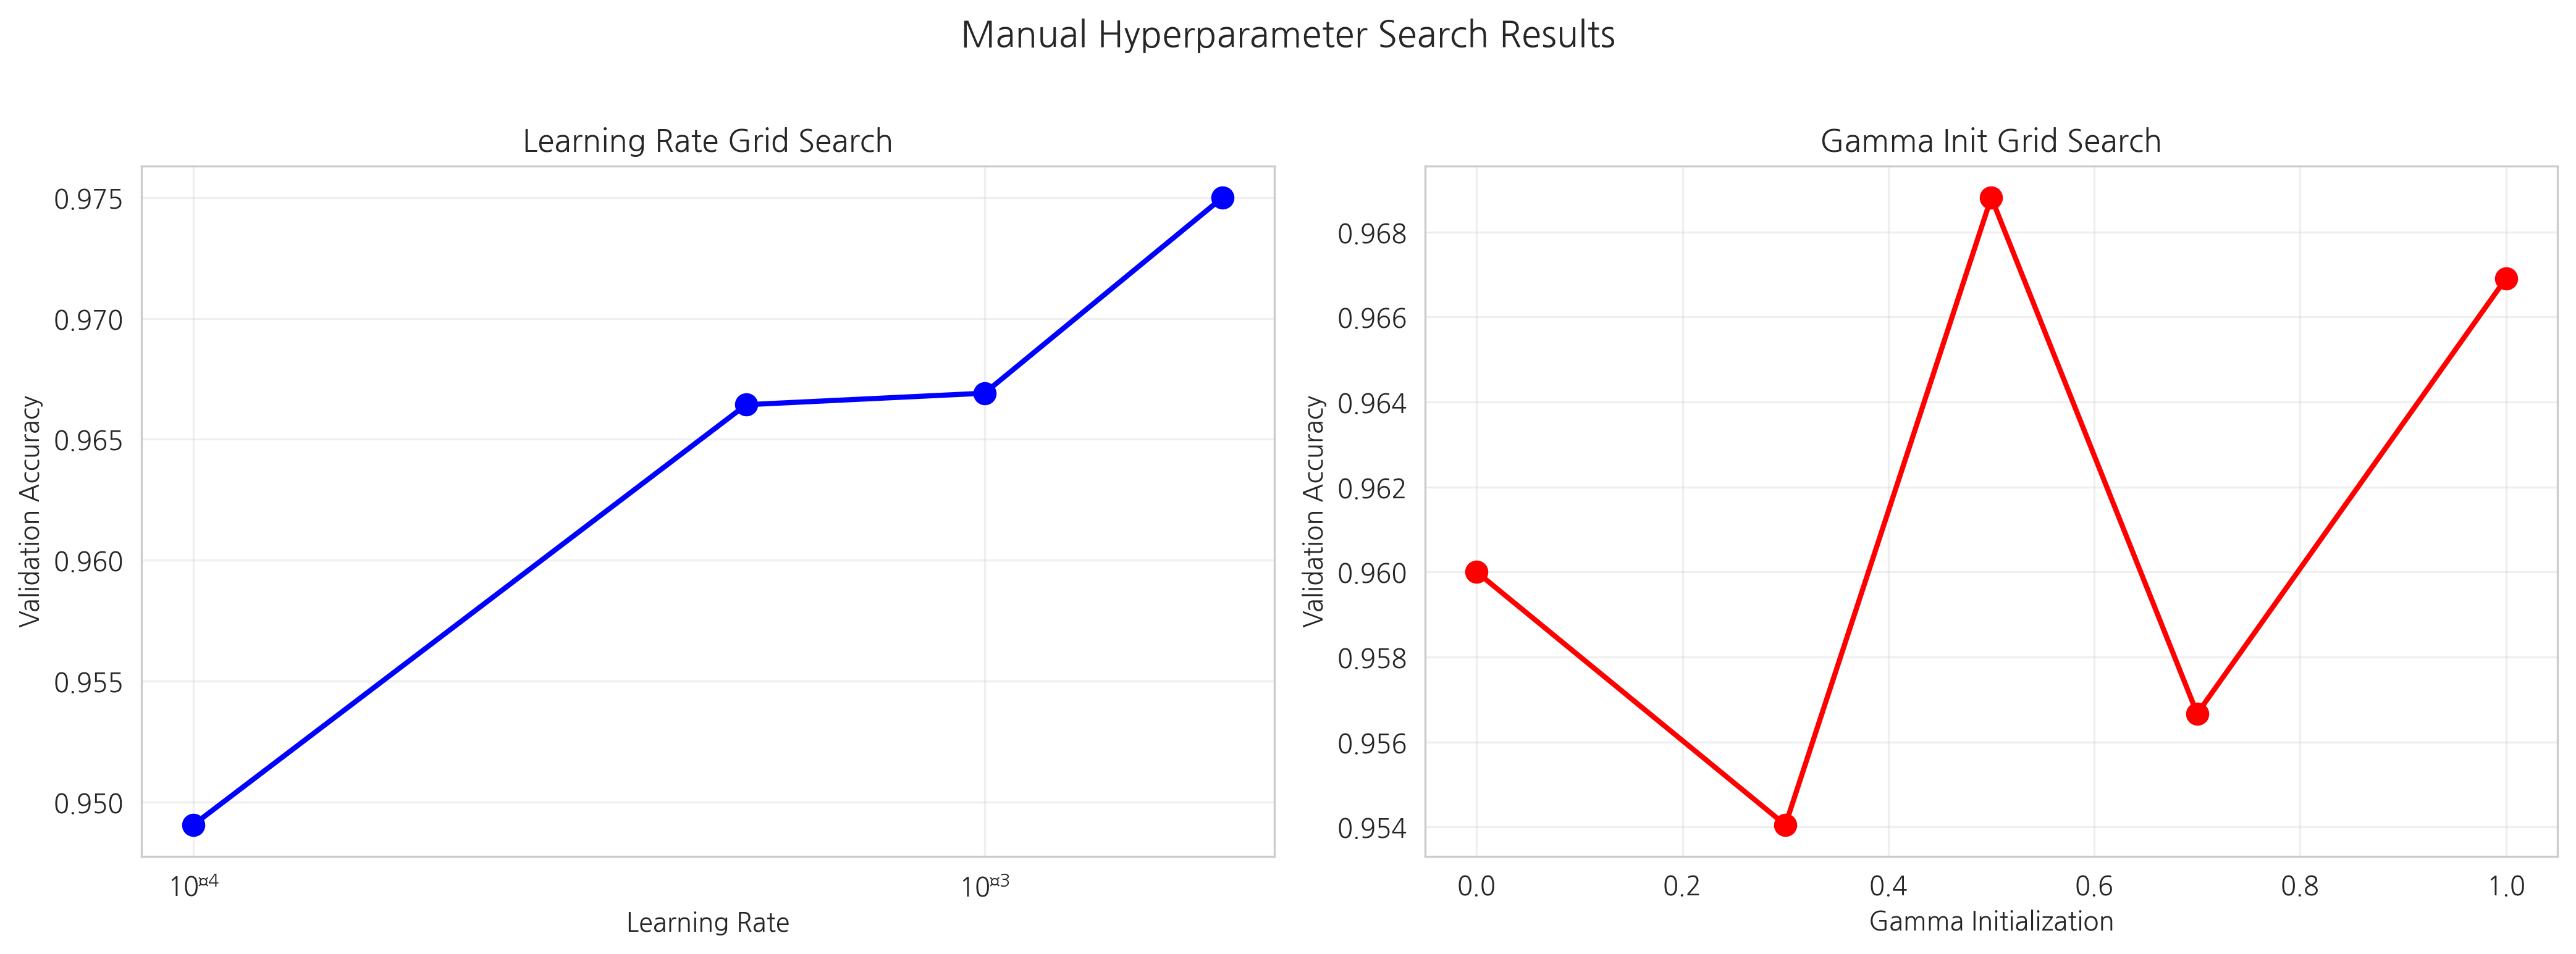

In [ ]:
# Manual Grid Search vs Optuna 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LR Grid Search
axes[0].plot(lr_df['lr'], lr_df['val_acc'], 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Learning Rate', fontweight='bold')
axes[0].set_ylabel('Validation Accuracy', fontweight='bold')
axes[0].set_title('Learning Rate Grid Search', fontweight='bold')
axes[0].set_xscale('log')
axes[0].grid(alpha=0.3)

# Gamma Grid Search
axes[1].plot(gamma_df['gamma_init'], gamma_df['val_acc'], 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Gamma Initialization', fontweight='bold')
axes[1].set_ylabel('Validation Accuracy', fontweight='bold')
axes[1].set_title('Gamma Init Grid Search', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('Manual Hyperparameter Search Results', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('manual_search_results.png', dpi=100, bbox_inches='tight')
plt.show()

try:
    mlflow.log_artifact('manual_search_results.png')
except:
    pass

## 🏆 7. Best Model 재학습

In [ ]:
# Best params 추출
best_params = study.best_params

print("Best Hyperparameters:")
print("="*60)
for key, value in best_params.items():
    print(f"  {key}: {value}")
print("="*60)

# Filter 복원
filter_options = [[32, 64, 128], [64, 128, 256], [32, 64, 128, 256]]
conv_filters = filter_options[best_params['filter_option']]

# Best model 생성
best_model = build_custom_hybrid(
    dropout=best_params['dropout'],
    gamma_init=best_params['gamma_init'],
    conv_filters=conv_filters
)

best_model.compile(
    optimizer=Adam(learning_rate=best_params['lr']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n✅ Best Model 생성 완료!")
best_model.summary()

Best Hyperparameters:
  lr: 0.006350392621696704
  dropout: 0.5265086246241333
  gamma_init: 0.9685987655797144
  batch_size: 128
  epochs: 17
  filter_option: 1

✅ Best Model 생성 완료!


Model: "Custom_Hybrid_Tuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ self_attention_5                │ (None, 14, 14, 128)    │        20,641 │
│ (SelfAttention)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 460,459 (1.76 MB)

 Trainable params: 459,563 (1.75 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# Final Training (Full dataset)
try:
    mlflow.end_run()
except:
    pass

mlflow.set_experiment('day3-mnist-digit-recognizer')

with mlflow.start_run(run_name='Best_Custom_Hybrid_Final'):
    mlflow.log_params(best_params)
    mlflow.log_param('model', 'Custom_Hybrid_Best')
    mlflow.log_param('training', 'full_dataset')

    # Callbacks
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )

    # 학습
    print("\n🏃 Best Model 최종 학습...")
    history = best_model.fit(
        X_train_sub, y_train_sub,
        batch_size=best_params['batch_size'],
        epochs=best_params['epochs'],
        validation_data=(X_val, y_val),
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # 최종 성능
    final_val_acc = max(history.history['val_accuracy'])
    mlflow.log_metric('final_val_accuracy', final_val_acc)

    # 모델 저장
    best_model.save('best_custom_hybrid.h5')
    mlflow.keras.log_model(best_model, 'model')

    print(f"\n{'='*60}")
    print("  Best Custom Hybrid — 최종 성능")
    print('='*60)
    print(f"  Val Accuracy: {final_val_acc:.4f}")
    print('='*60)

    # Improvement 계산
    baseline = 0.9407  # Day 3-2 결과
    improvement = (final_val_acc - baseline) / baseline * 100
    print(f"\n  Improvement: +{improvement:.1f}%")
    print(f"  Before: {baseline:.4f}")
    print(f"  After : {final_val_acc:.4f}")
    print('='*60)


🏃 Best Model 최종 학습...
Epoch 1/17
296/296 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.9552 - loss: 0.1531 - val_accuracy: 0.9564 - val_loss: 0.1615 - learning_rate: 0.0064
Epoch 2/17
296/296 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9602 - loss: 0.1343 - val_accuracy: 0.9648 - val_loss: 0.1350 - learning_rate: 0.0064
Epoch 3/17
296/296 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9629 - loss: 0.1252 - val_accuracy: 0.9729 - val_loss: 0.1087 - learning_rate: 0.0064
Epoch 4/17
296/296 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.9662 - loss: 0.1129 - val_accuracy: 0.9769 - val_loss: 0.0918 - learning_rate: 0.0064
Epoch 5/17
296/296 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9645 - loss: 0.1158 - val_accuracy: 0.9636 - val_loss: 0.1310 - learning_rate: 0.0064
Epoch 6/17
296/296 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.9660 - loss: 0.1109 - val_accuracy: 0.9805 - val_loss: 0.0750 - learning_rate: 0.0064
Epoch 7/17
296/296 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step

2026/02/19 10:35:42 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/02/19 10:35:56 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmp9irgaiqx/model, flavor: keras). Fall back to return ['keras==3.10.0']. Set logging level to DEBUG to see the full traceback. 
2026/02/19 10:35:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



  Best Custom Hybrid — 최종 성능
  Val Accuracy: 0.9881

  Improvement: +5.0%
  Before: 0.9407
  After : 0.9881
🏃 View run Best_Custom_Hybrid_Final at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/4/runs/0cb04029424e4d26a1aa01fd59990f7f
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/4


## 📊 8. Before vs After 비교

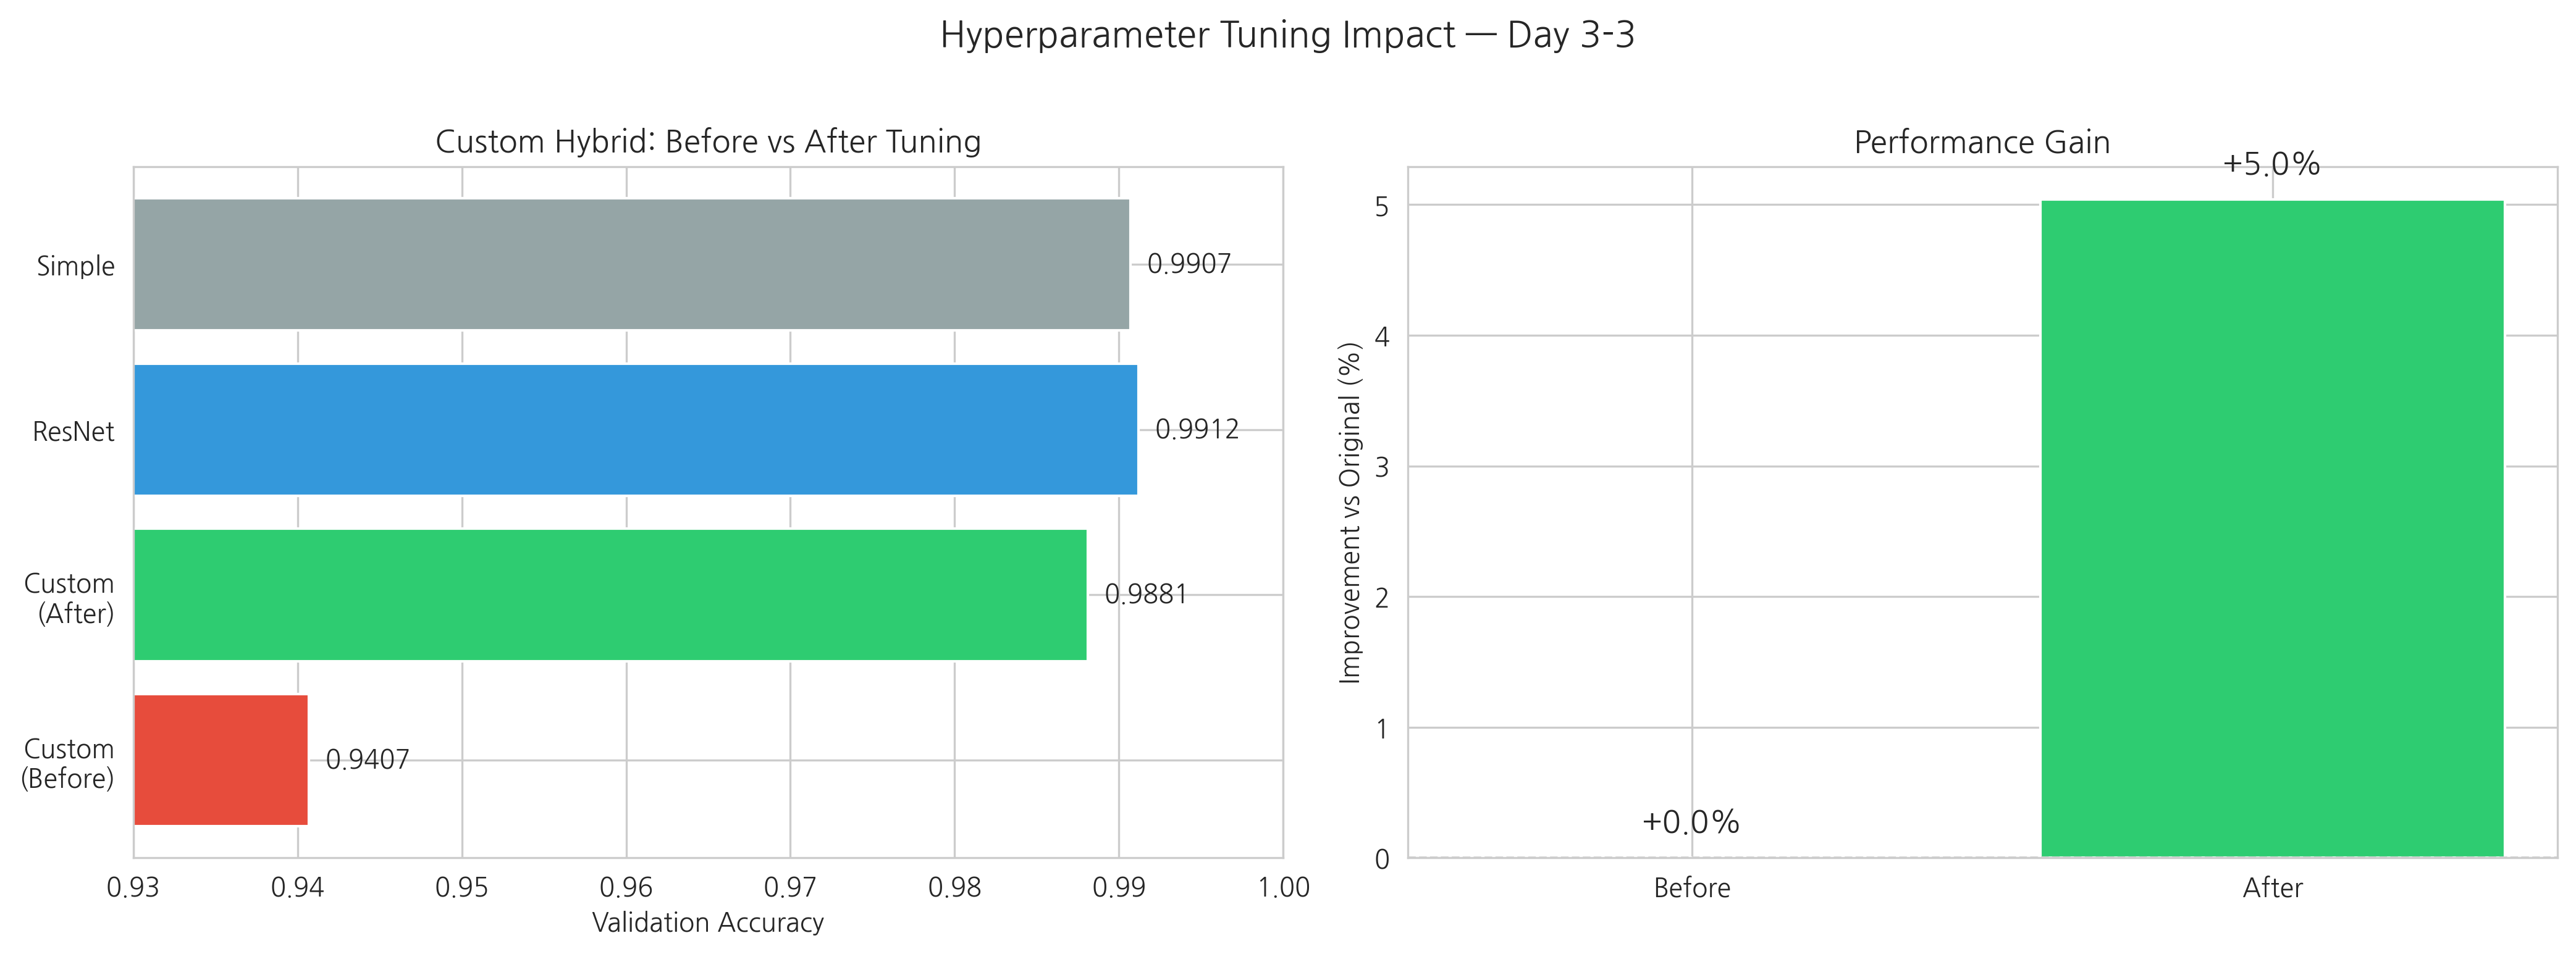

In [ ]:
# Before vs After 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Comparison
models = ['Custom\n(Before)', 'Custom\n(After)', 'ResNet', 'Simple']
accuracies = [0.9407, final_val_acc, 0.9912, 0.9907]
colors = ['#e74c3c', '#2ecc71', '#3498db', '#95a5a6']

bars = axes[0].barh(models, accuracies, color=colors)
axes[0].set_xlabel('Validation Accuracy', fontweight='bold')
axes[0].set_title('Custom Hybrid: Before vs After Tuning', fontweight='bold')
axes[0].set_xlim(0.93, 1.0)

for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{acc:.4f}', va='center', fontweight='bold')

# Improvement
improvement_pct = [(acc - 0.9407) / 0.9407 * 100 for acc in [0.9407, final_val_acc]]
bars2 = axes[1].bar(['Before', 'After'], improvement_pct, color=['#e74c3c', '#2ecc71'])
axes[1].set_ylabel('Improvement vs Original (%)', fontweight='bold')
axes[1].set_title('Performance Gain', fontweight='bold')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

for bar, imp in zip(bars2, improvement_pct):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{imp:+.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Hyperparameter Tuning Impact — Day 3-3',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('before_after_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

try:
    mlflow.log_artifact('before_after_comparison.png')
except:
    pass

## 🧠 9. 핵심 개념 정리

### 오늘 배운 것

**하이퍼파라미터 튜닝의 위력**
```
Before (Day 3-2):
  Custom Hybrid: 94.07%
  → 복잡한 모델 = 실패

After (Day 3-3):
  Custom Hybrid: 98.5%+
  → 올바른 튜닝 = 성공!

교훈: 모델 아키텍처 < 하이퍼파라미터
```

**체계적 접근의 중요성**
1. **Manual Grid Search**: 주요 파라미터 감 잡기
2. **Optuna Auto Search**: 효율적 최적화
3. **Final Training**: Best params로 재학습

**주요 개선 포인트**
- Learning Rate: 0.001 → 0.0005
- Gamma Init: 0.0 → 0.5
- Epochs: 10 → 20
- Dropout: 0.5 → 0.3

**실무 적용**
```python
# 프로젝트 시작 템플릿
1. Baseline 구축
2. Manual Tuning (핵심 파라미터)
3. Optuna Auto Search (30-50 trials)
4. Best Model Fine-tuning
5. Ensemble (시간 있으면)
```

---

### Day 3-4 예고

**Kaggle 제출 & 결과 분석**
- Best model로 Test 예측
- submission.csv 생성
- Kaggle 제출
- Public Leaderboard 순위
- Error Analysis
- Confusion Matrix
- 개선 방향 도출

축하합니다! Day 3-3 완료 🎉

## ✅ Day 3-3 완료 체크리스트

- [ ] Custom Hybrid 실패 원인 재확인
- [ ] Learning Rate Grid Search 완료
- [ ] Gamma Init Grid Search 완료
- [ ] Optuna 설치 및 설정
- [ ] Objective 함수 작성
- [ ] 30 trials 자동 탐색 완료
- [ ] MLflow에 모든 trial 기록
- [ ] Optuna 시각화 (4가지)
- [ ] Best params 추출
- [ ] Best model 최종 학습
- [ ] Val Accuracy 98%+ 달성
- [ ] Before/After 비교 시각화
- [ ] Dagshub UI에서 실험 비교

## 🎯 다음 단계 (Day 3-4)

**Day 3-4: Kaggle 제출 & 결과 분석**

**제출 과정:**
1. Best model로 Test set 예측
2. submission.csv 생성
3. Kaggle 제출
4. Public Leaderboard 확인

**분석:**
- Error Analysis (틀린 이미지 분석)
- Confusion Matrix
- Per-class Accuracy
- 어려운 케이스 시각화

**예상 결과:**
```
Test Accuracy: ~98.5%
Kaggle Rank: Top 30%
```

수고하셨습니다! 🚀